In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.filters as flt
import matplotlib.patches as patches

import sys
sys.path.append('../01_scripts/')

import amglib.readers as rd
import amglib.imageutils as amg

## Read images

In [56]:
img = rd.read_images('../02_rawdata/02_pool_L/24_force_{0:05d}.fits', first=1, last=4)
ob = np.median(rd.read_images('../02_rawdata/04_ref/lightON/ob_{0:05d}.fits', first=1, last=3),axis=0)
dc = np.median(rd.read_images('../02_rawdata/04_ref/lightON/dc_{0:05d}.fits', first=1, last=3),axis=0)
img0=flt.median(img,footprint=np.ones([1,5,5]))


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

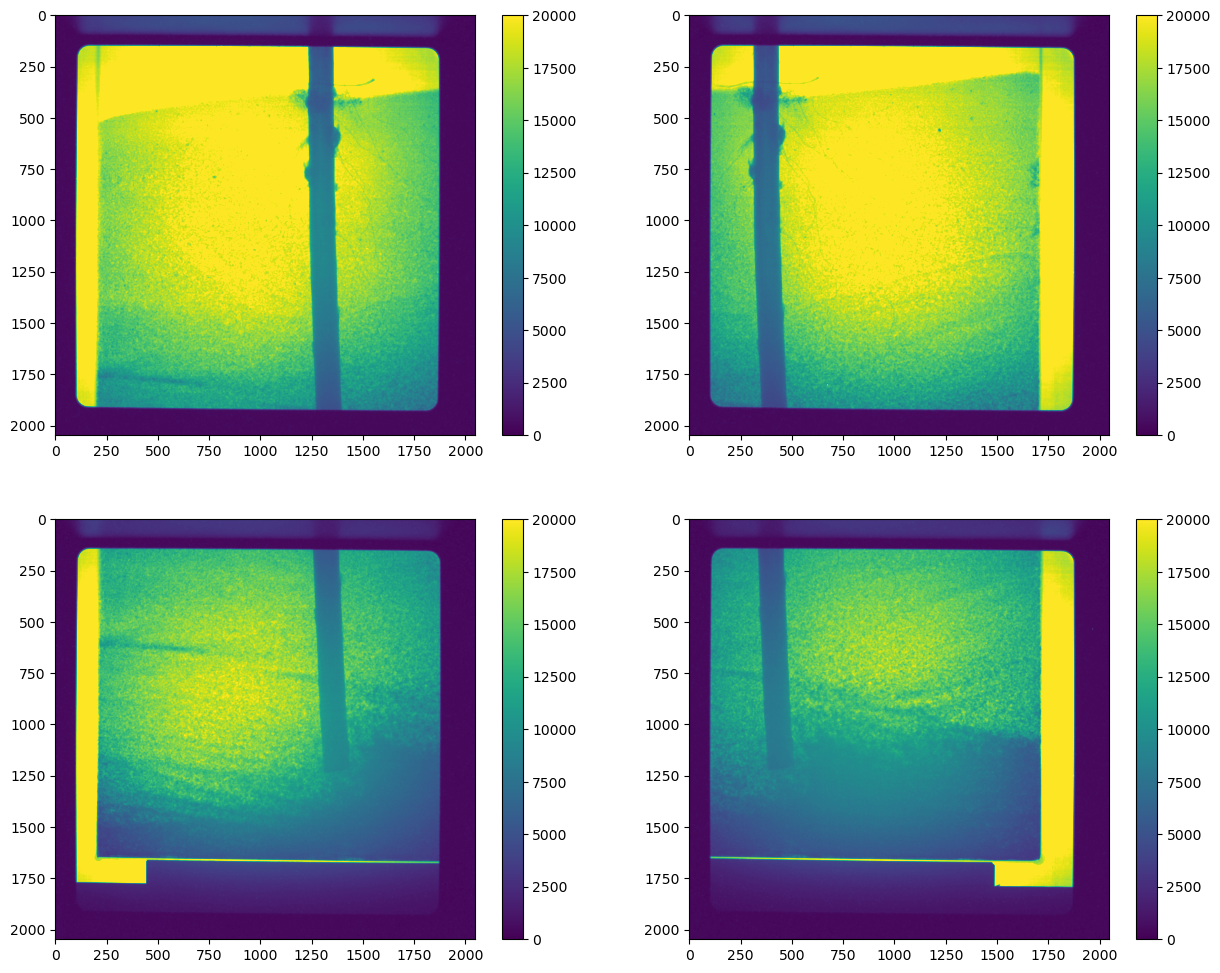

In [57]:
fig,ax = plt.subplots(2,2,figsize=(15,12))

ax=ax.ravel()
img=np.copy(img0)
for idx,a in enumerate(ax) :
    aa=a.imshow(img0[idx,::-1,:],vmin=0.,vmax=20000)
    fig.colorbar(aa,ax=a)

### Normalization and cropping

In [58]:
ob = ob - dc 
ob[ob<1]=1

img=np.copy(img0)
doses = [[1250,120,1300,180],[1250,1800,1300,1850],[1250,120,1300,180],[1250,1800,1300,1850]]
for idx in range(4) :
    tmp=img[idx]-dc
    tmp[tmp<1]=1
    D = np.median(tmp[doses[idx][0]:doses[idx][2],doses[idx][1]:doses[idx][3]])
    D0= np.median(ob[doses[idx][0]:doses[idx][2],doses[idx][1]:doses[idx][3]].mean())
    print(D,D0)
    img[idx]= D0/D*tmp/ob

img=img[:,200:1800,150:1750]
img=img[:,::-1,:]

23914.5 22609.686
22474.0 21239.252
24636.0 22609.686
22906.0 21239.252


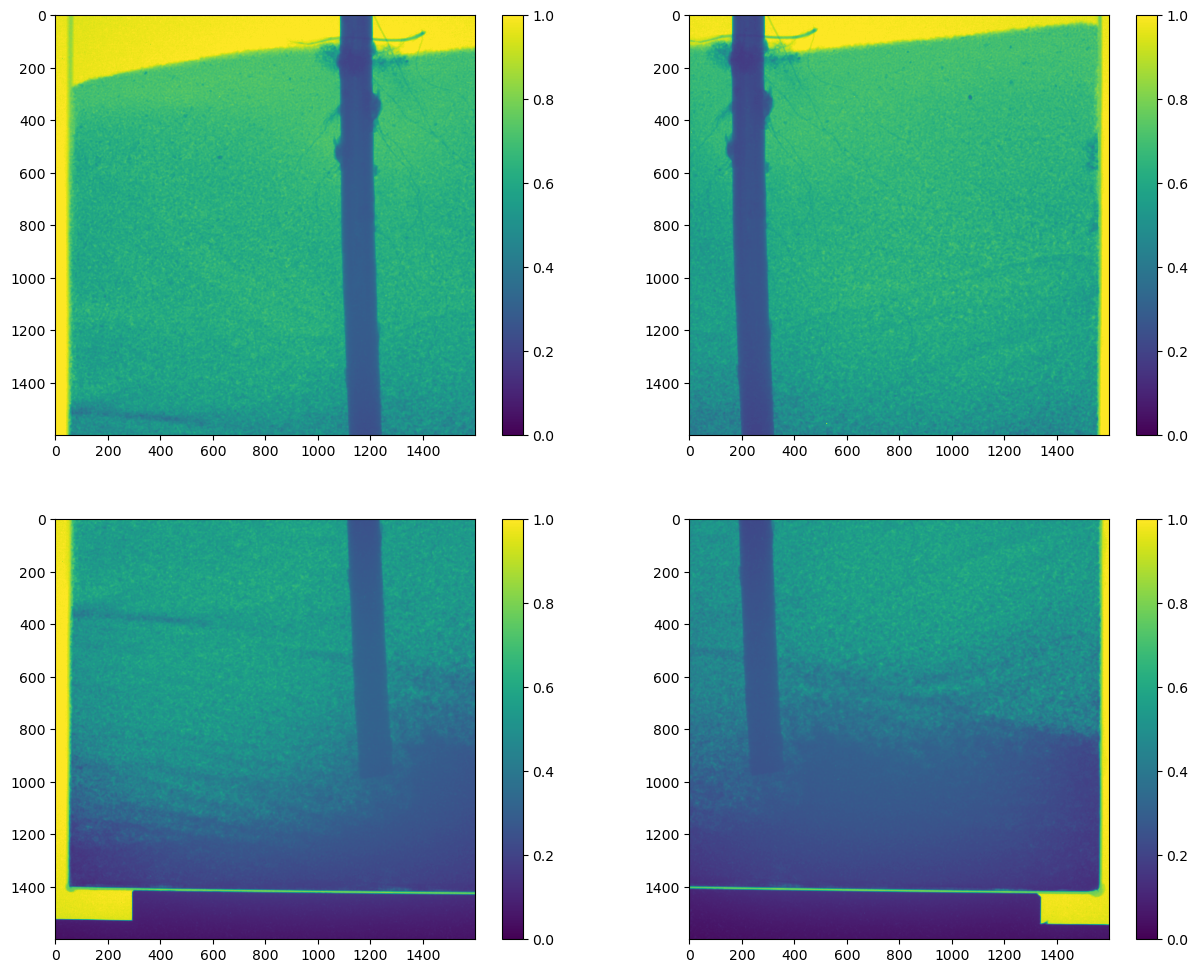

In [61]:
fig,ax = plt.subplots(2,2,figsize=(15,12))

ax=ax.ravel()

for idx,a in enumerate(ax) :
    aa=a.imshow(img[idx],vmin=0.,vmax=1)
    fig.colorbar(aa,ax=a)

## Putting the images together
Here we use the array concatenation method without any adjustment

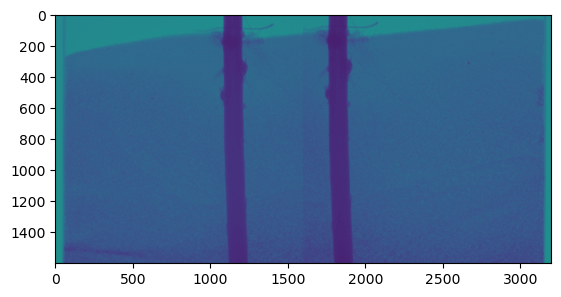

In [60]:
a = np.concatenate((img[0],img[1]),axis=1)
plt.imshow(a)

### Finding common points
We compare a slab of one image to find the corresponding position in the other. 

$$MSE=\sum_{x \in \Omega} (a(x)-b(x))^2$$

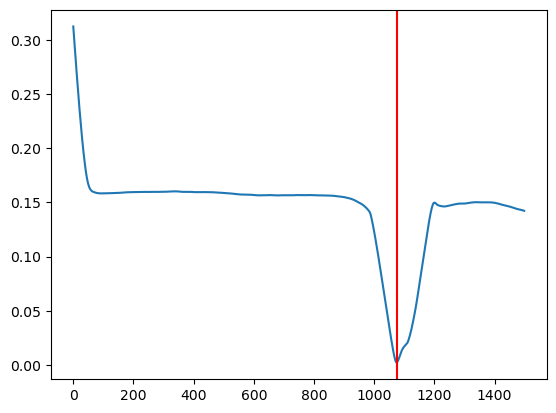

In [38]:
def corr_h(img,slab) :
    N=img.shape[1]-slab.shape[1]-1
    res = np.zeros(N);
    for i in range(N) :
        res[i]=((img[:,i:(i+slab.shape[1])]-slab)**2).mean()
        
    return res

def corr_v(img,slab) :
    N=img.shape[0]-slab.shape[0]-1
    res = np.zeros(N);
    for i in range(N) :
        res[i]=((img[i:(i+slab.shape[0]),:]-slab)**2).mean()
        
    return res
bpos=150
Nslab=100
p=corr_h(img[0],img[1,:,bpos:(bpos+Nslab)])
plt.plot(p)
hpos=np.argmin(p)
plt.axvline(hpos,color='r')

Find minimum of MSE curve. This is where the images match

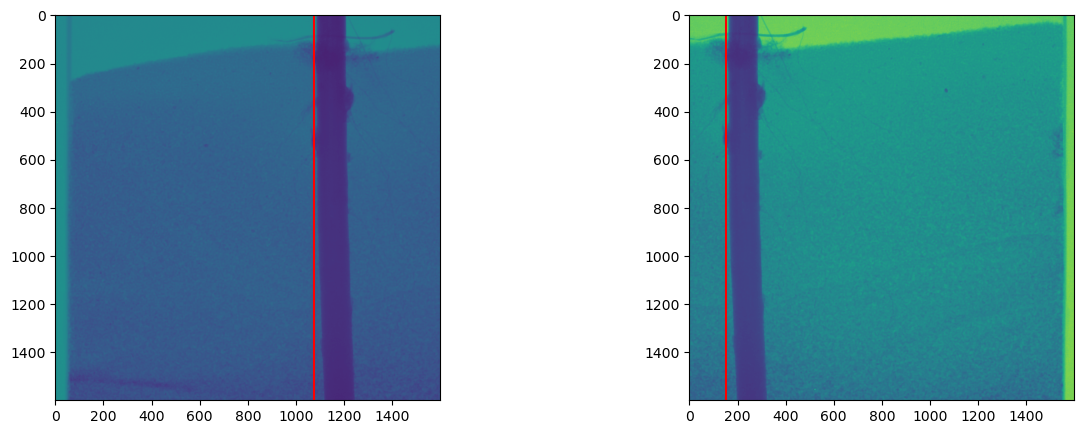

In [39]:

fig,ax=plt.subplots(1,2,figsize=(15,5))
ax[0].imshow(img[0])
ax[0].axvline(hpos
              ,color='r')
ax[1].imshow(img[1])
ax[1].axvline(bpos,color='r')

Concatenate the images on this cut point

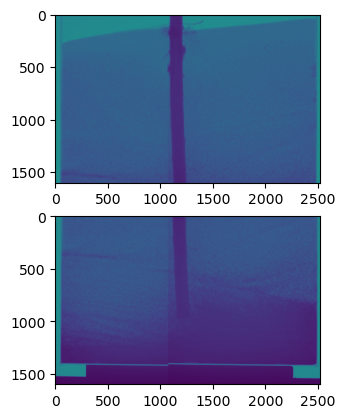

In [44]:
a = np.concatenate((img[0,:,:(hpos)],img[1,:,bpos:]),axis=1)
b = np.concatenate((img[2,:,:(hpos)],img[3,:,bpos:]),axis=1)

fig,ax=plt.subplots(2,1)
ax[0].imshow(a)
ax[1].imshow(b)


Search got the min of the vertical MSE curve

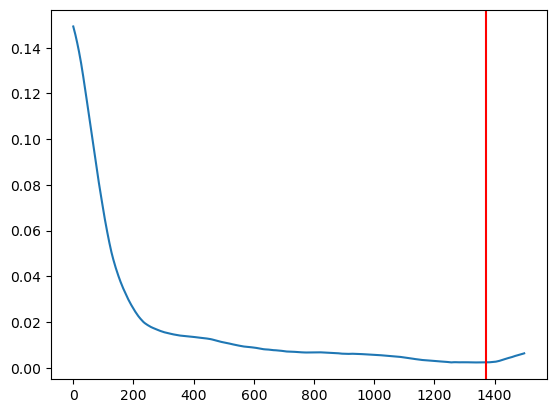

In [45]:
cpos=100
vp=corr_v(a,b[cpos:(cpos+Nslab)])
plt.plot(vp)
vpos=np.argmin(vp)
plt.axvline(vpos,color='r')

Concatenate the upper and lower parts

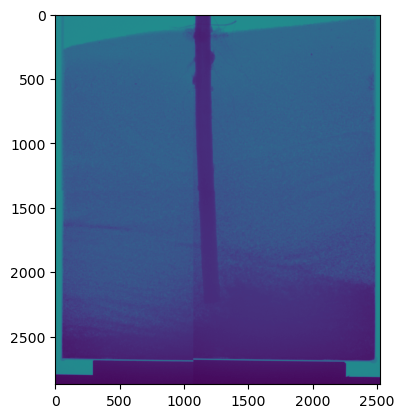

In [46]:
c = np.concatenate((a[:vpos,:],b[100:,:]),axis=0)

plt.imshow(c)

## Use a function for the concatenation

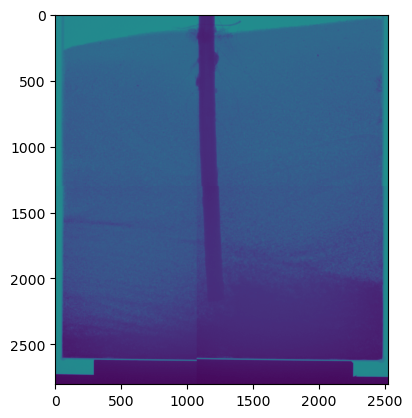

In [53]:
def build_mosaic(img,hpos,vpos):
    a = np.concatenate((img[0,:,:hpos[0]],img[1,:,hpos[1]:]),axis=1)
    b = np.concatenate((img[2,:,:hpos[0]],img[3,:,hpos[1]:]),axis=1)
    c = np.concatenate((a[:vpos[0],:],b[vpos[1]:,:]),axis=0)
    
    return c

hpos = np.argmin(corr_h(img[0],img[1,:,150:250]))
vpos = np.argmin(corr_v(img[0],img[2,150:250]))
res=build_mosaic(img,hpos=[hpos,bpos],vpos=[vpos,cpos])
plt.imshow(res)

## Final note
The concatenation this way is an easy approach. I can howevefr notice that there were positioning errors. These must be handled with additional MSE for better accuracy.

Concatenation is also an abrupt way. It would be better to do a linear interpolation between the images for smoother transition. 